# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Generate Pseudo-Absence Data
Absence data must be generated for these classifiers, and different quantities must be generated for types of classifiers, based on Barbet-Massin et al., 2012.

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [7]:
import os
# os.mkdir("inputs", ex)
# os.mkdir("outputs")
import subprocess

command = ["C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe",'pseudo_absence.R', 
           'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', "2", "northerncorn"]
subprocess.run(command, check = True)

CompletedProcess(args=['C:\\Users\\chenst-intern\\AppData\\Local\\Programs\\R\\R-4.6.1\\bin\\x64\\Rscript.exe', 'pseudo_absence.R', 'pests\\northern_corn_rootworm_0003360-260623161305970\\ncr.csv', '2', 'northerncorn'], returncode=0)

### Converting shapefiles (.shp) to geopandas dataframe

In [1]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf = gpd.GeoDataFrame.from_file('data/ncr.shp')
ncr_gdf.sample(5)

,CLASS,geometry
136,1.0,POINT (-94.11846 45.50568)
716,1.0,POINT (-82.57748 39.9582)
697,1.0,POINT (-89.03136 40.6385)
333,1.0,POINT (-93.76865 44.7182)
544,1.0,POINT (-89.8599 43.33902)


Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [4]:
print("Number of duplicates: ", ncr_gdf.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf.crs))
print("{} observations with {} columns".format(*ncr_gdf.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
1442 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

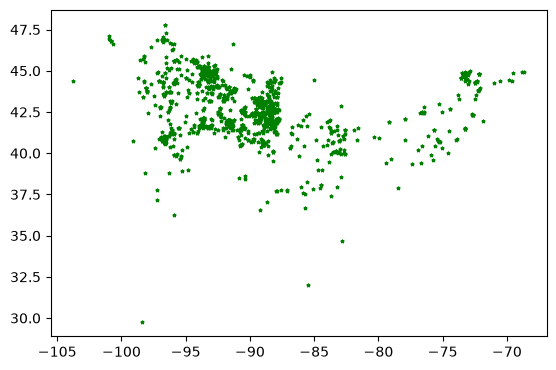

In [5]:
ncr_gdf[ncr_gdf.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

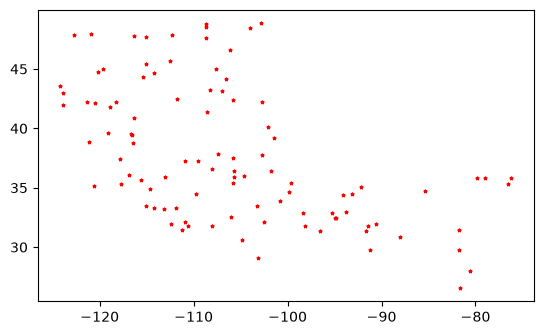

In [6]:
ncr_gdf[ncr_gdf.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [7]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
    'worldclim/wc2.1_2.5m_bio_*.tif'))

print('There are ', len(ras_feats), ' raster features.')


There are  7  raster features.


Generate raster maps of suitability

In [8]:
from pyimpute import load_training_vector
from pyimpute import load_targets

train_xs, train_y = load_training_vector(ncr_gdf, ras_feats, response_field='CLASS')
target_xs, raster_info = load_targets(ras_feats)
train_xs.shape, train_y.shape

((1442, 7), (1442,))

Classifier implementation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

CLASS_MAP = {
    'rf': (RandomForestClassifier()),
    'et': (ExtraTreesClassifier()),
    'xgb': (XGBClassifier()),
    'lgbm': (LGBMClassifier())
}

from pyimpute import impute
from sklearn import model_selection

for name, (model) in CLASS_MAP.items():
    # cross validation for accuracy scores (displayed as a percentage)
    k = 4 # k-fold
    kf = model_selection.KFold(n_splits=k, shuffle=True, random_state=42)
    accuracy_scores = model_selection.cross_val_score(model, train_xs, train_y, cv=kf, scoring='accuracy')
    print(name + " %d-fold Cross Validation Accuracy: %0.2f (+/- %0.2f)"
          % (k, accuracy_scores.mean() * 100, accuracy_scores.std() * 200))
    
    # spatial prediction
    model.fit(train_xs, train_y)
    os.mkdir('outputs/' + name + '-images')
    impute(target_xs, model, raster_info, outdir='outputs/' + name + '-images',
           class_prob=True, certainty=True)

rf 5-fold Cross Validation Accuracy: 99.65 (+/- 1.08)
et 5-fold Cross Validation Accuracy: 99.65 (+/- 1.08)
xgb 5-fold Cross Validation Accuracy: 99.38 (+/- 0.81)
[LightGBM] [Info] Number of positive: 1070, number of negative: 83
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1417
[LightGBM] [Info] Number of data points in the train set: 1153, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.928014 -> initscore=2.556573
[LightGBM] [Info] Start training from score 2.556573
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Total Bins 1412
[LightGBM] [Info] Number of data points in the train set: 1154, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.934142 -> initscore=2.652129
[LightGBM] [Info] Start training from score 2.652129
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\chenst-intern\OneDrive - World Wildlife Fund, Inc\Documents\sdm\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\che

Averaging the outputs of the models, and plotting it onto a map

C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
C:\Users\chenst-intern\AppData\Local\Temp\ipykernel_15036\1924409663.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
C:\U

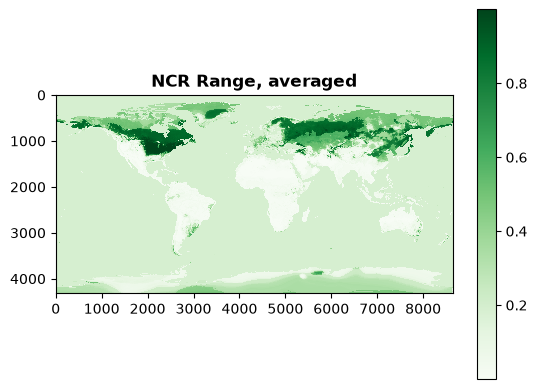

In [11]:
from pylab import plt
# define spatial plotter
def plotit(x, title, cmap="Blues"):
    plt.imshow(x, cmap=cmap, interpolation='nearest')
    plt.colorbar()
    plt.title(title, fontweight = 'bold')

import rasterio
distr_rf = rasterio.open("outputs/rf-images/probability_1.0.tif").read(1)
distr_et = rasterio.open("outputs/et-images/probability_1.0.tif").read(1)
distr_xgb =  rasterio.open("outputs/xgb-images/probability_1.tif").read(1)
distr_lgbm =  rasterio.open("outputs/lgbm-images/probability_1.0.tif").read(1)
distr_averaged = (distr_rf + distr_et + distr_xgb + distr_lgbm)/4  

plotit(distr_averaged, "NCR Range, averaged", cmap="Greens")